In [ ]:
# ! pip install yfinance
import Ab as ab
import datetime as dt
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get data from yahoo finance
sd = dt.datetime(1998,12,4)
ed = dt.datetime(2025,7,18)
# 1x leveraged nasdaq 100 etf
qqq = ab.StockData('QQQ')
qqq.get_data_from_yfinance('QQQ', sd, ed)
# 2x leveraged nasdaq 100 etf
qld = ab.StockData('QLD')
qld.get_data_from_yfinance('QLD', sd, ed)
# 3x leveraged nasdaq 100 etf
tqqq = ab.StockData('TQQQ')
tqqq.get_data_from_yfinance('TQQQ', sd, ed)
#nasdaq 100 index
ndx = ab.StockData('NDX')
ndx.get_data_from_yfinance('NDX', sd, ed)
#S&P 500 etf
spy = ab.StockData('SPY')
spy.get_data_from_yfinance('SPY', sd, ed)
#nasdaq stocks above 200 day moving average percentage
naa200r = ab.StockData('NAA200R')
naa200r.get_data_from_csv('data/NAA200R.csv')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [8]:


def naa200r_performance(ticker, sd, ed, signal_ma_window = 20, buy_threshold = 15 , sell_threshold = 30,  visualization=True):

    signal_data = naa200r.data.sort_index().loc[sd:ed].copy()
    ticker_data = ticker.data.sort_index().loc[sd:ed].copy()
    ticker_name = ticker.ticker

    threshold_strategy = ab.Threshold(name = 'NAA200R',
                                    buy_threshold = buy_threshold , sell_threshold = sell_threshold ,
                                    signal_ma_window=signal_ma_window )

    # run strategy
    threshold_strategy.run_strategy(naa200r, sd , ed)
    naa200r_threshold_bt = ab.BackTest()
    naa200r_threshold_bt.run_backtest(threshold_strategy, ticker, sd , ed)
    print(naa200r_threshold_bt.performance_summary())


    if visualization == True:

        # get trade list
        df_balance = naa200r_threshold_bt.balance
        df_balance['Trade'] = np.where(df_balance['Stock'].diff()>0, 1, np.where(df_balance['Stock'].diff()<0, -1, 0))

        # plots
        fig = plt.figure(figsize=(16,4))
        signal_data['Close'].plot(label='NAA200R')
        signal_data['Close'].rolling(signal_ma_window).mean().plot(label='NAA200R MA{}'.format(signal_ma_window))


        plt.axhline(y = 15, color = 'black', linestyle='dashed')
        plt.axhline(y = 30, color = 'black', linestyle='dashed')

        trades = df_balance.loc[df_balance['Trade']!=0]
        for idx, row in trades.iterrows():
            if row['Trade']<0:
                plt.axvline(x=idx, color = 'red', linestyle='dashed')
            if row['Trade']>0:
                plt.axvline(x=idx, color = 'green', linestyle='dashed')

        plt.ylim([0, 50])
        plt.title('Trading Signals And NAA200R')
        plt.legend()
        plt.show()

        fig = plt.figure(figsize=(16,4))
        ticker_data['Close'].plot()

        trades = df_balance.loc[df_balance['Trade']!=0]
        for idx, row in trades.iterrows():
            if row['Trade']<0:
                plt.axvline(x=idx, color = 'red', linestyle='dashed')
            if row['Trade']>0:
                plt.axvline(x=idx, color = 'green', linestyle='dashed')
        plt.title('Trading Signals And {}'.format(ticker_name))
        plt.show()

        fig = plt.figure(figsize=(16,4))
        df_balance.plot(y = 'Total', title = 'Portfolio Performance of {}'.format(ticker_name), figsize=(16,4))


NAA200R 15/50 MA 50:
cumulative return      : 535.00%
compound anual return  : 9.2012%
max_drawdown           : -28.66%
sharp_ratio            : 4.25%
average of daily return: 0.0388%
std of daily return    : 0.9141%
number of trades       : 97,
trading days           : 7741,
batting Average        : 40.62%
Gain Average           : 9.02%
Loss Average           : -2.32%
Risk Reward Ratio      : 3.88
Gain STD               : 10.56%
Loss STD               : 2.36%
        
None


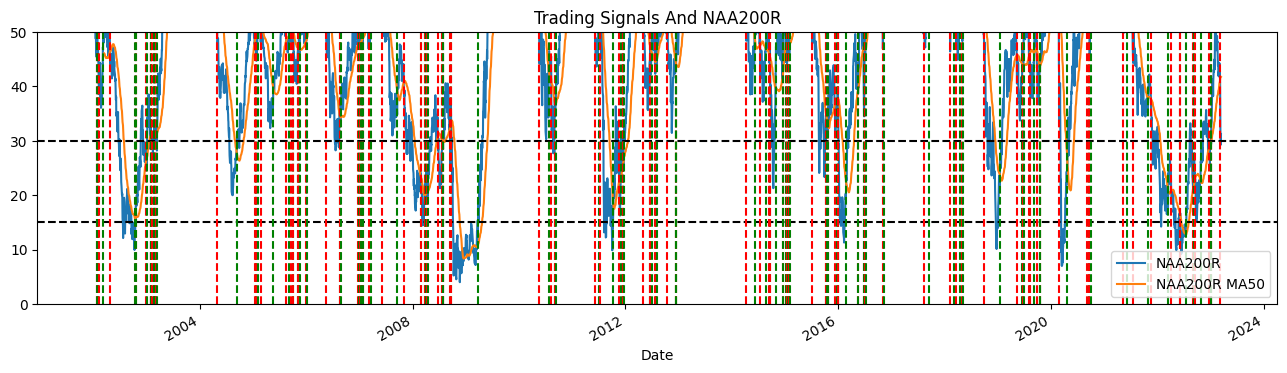

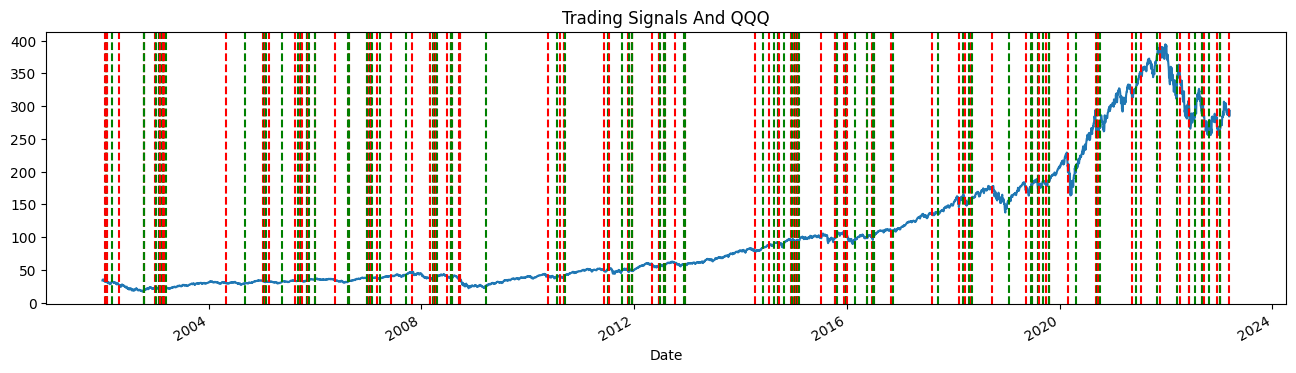

<Figure size 1600x400 with 0 Axes>

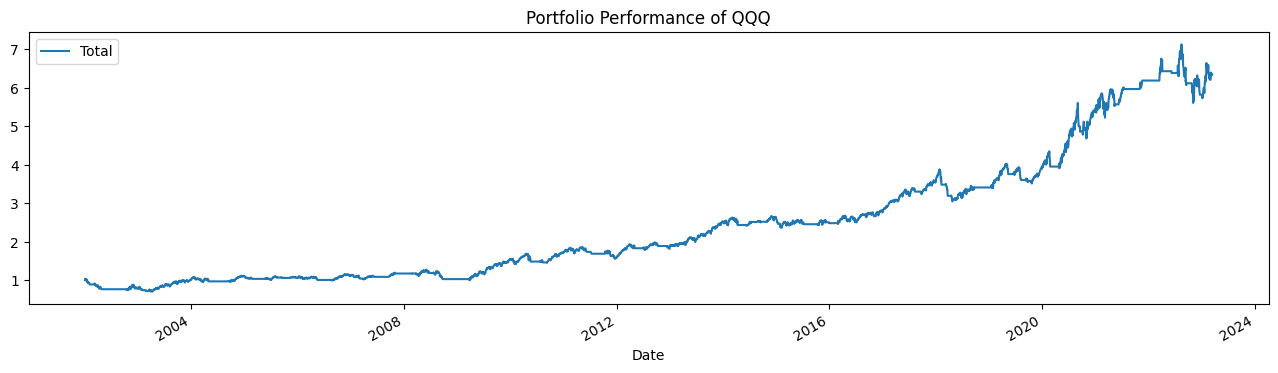

In [9]:

sd = dt.datetime(2002,1,1)
ed = dt.datetime(2023,3,14)
signal_ma_window = 50
buy_threshold = 15
sell_threshold = 50
ticker = qqq

naa200r_performance(ticker, sd, ed, signal_ma_window, buy_threshold , sell_threshold,  visualization=True)


NAA200R 15/30 MA 20:
cumulative return      : 6288.69%
compound anual return  : 27.7029%
max_drawdown           : -43.97%
sharp_ratio            : 5.76%
average of daily return: 0.1213%
std of daily return    : 2.1037%
number of trades       : 43,
trading days           : 6097,
batting Average        : 40.48%
Gain Average           : 53.12%
Loss Average           : -5.88%
Risk Reward Ratio      : 9.03
Gain STD               : 77.30%
Loss STD               : 4.09%
        
None


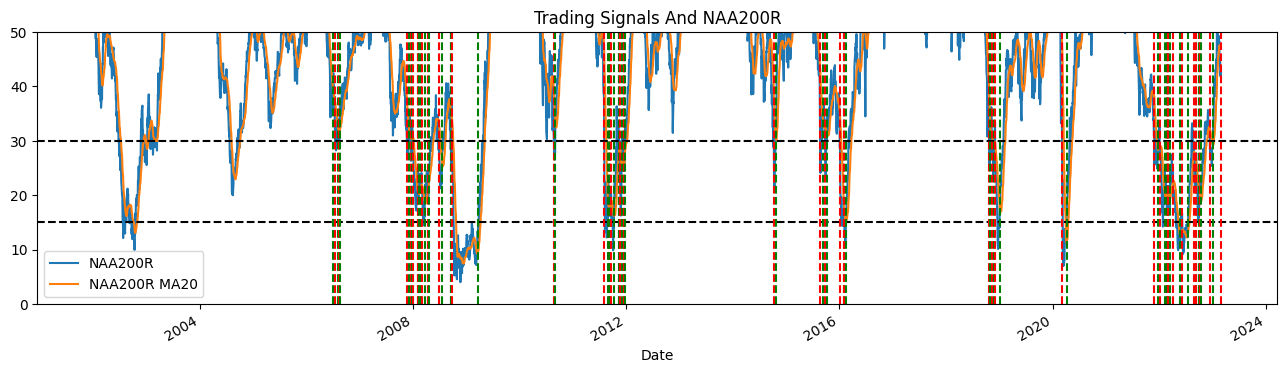

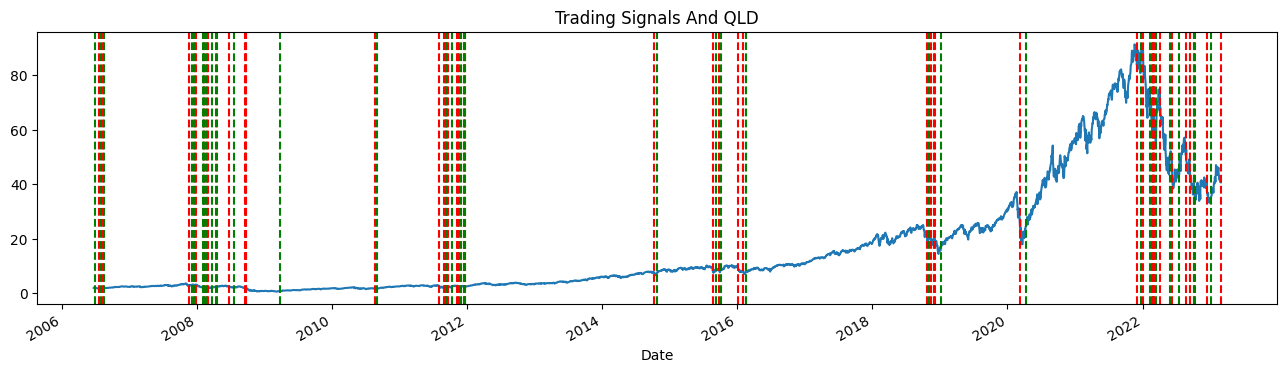

<Figure size 1600x400 with 0 Axes>

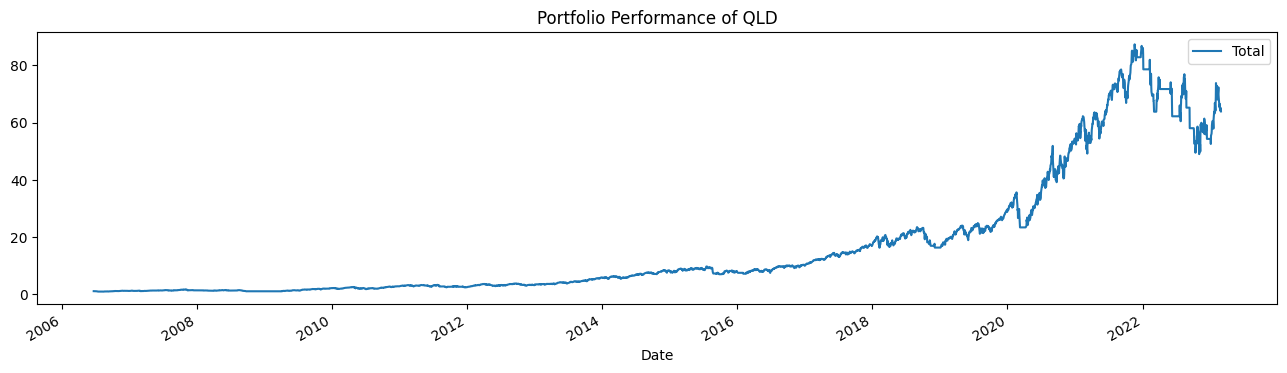

In [10]:
sd = dt.datetime(2002,1,1)
ed = dt.datetime(2023,3,1)
signal_ma_window = 20
buy_threshold = 15
sell_threshold = 30
ticker = qld

naa200r_performance(ticker, sd, ed, signal_ma_window, buy_threshold , sell_threshold,  visualization=True)


NAA200R 30/30 MA 50:
cumulative return      : 774.33%
compound anual return  : 9.4552%
max_drawdown           : -47.91%
sharp_ratio            : 4.04%
average of daily return: 0.0421%
std of daily return    : 1.0416%
number of trades       : 32,
trading days           : 8597,
batting Average        : 45.16%
Gain Average           : 29.37%
Loss Average           : -6.37%
Risk Reward Ratio      : 4.61
Gain STD               : 26.58%
Loss STD               : 7.88%
        
None


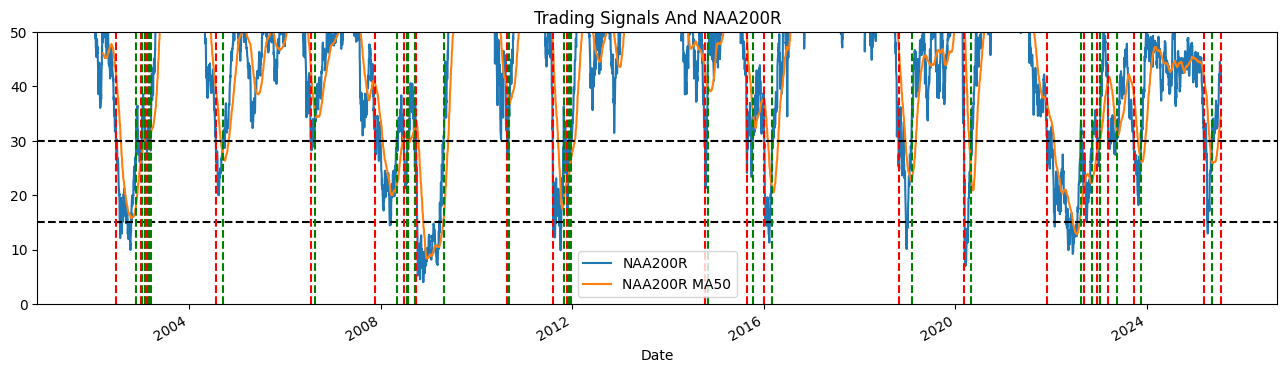

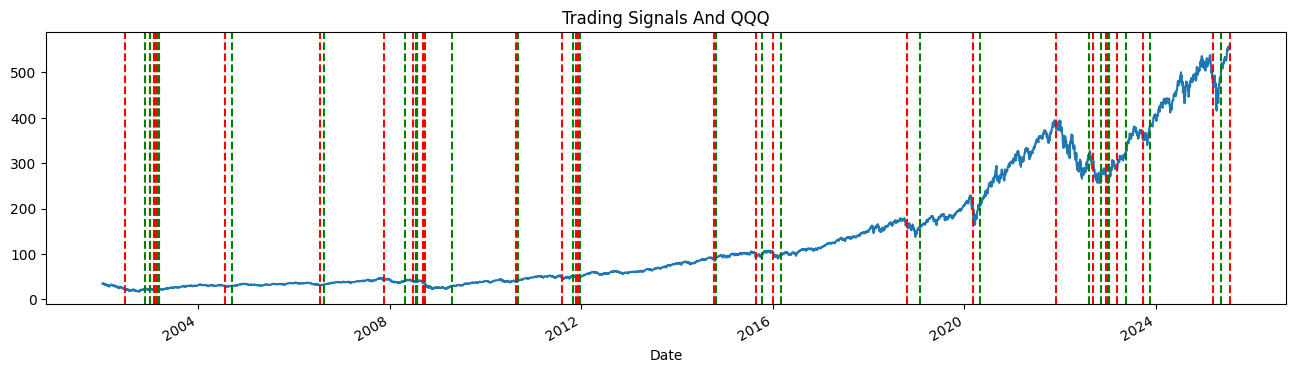

<Figure size 1600x400 with 0 Axes>

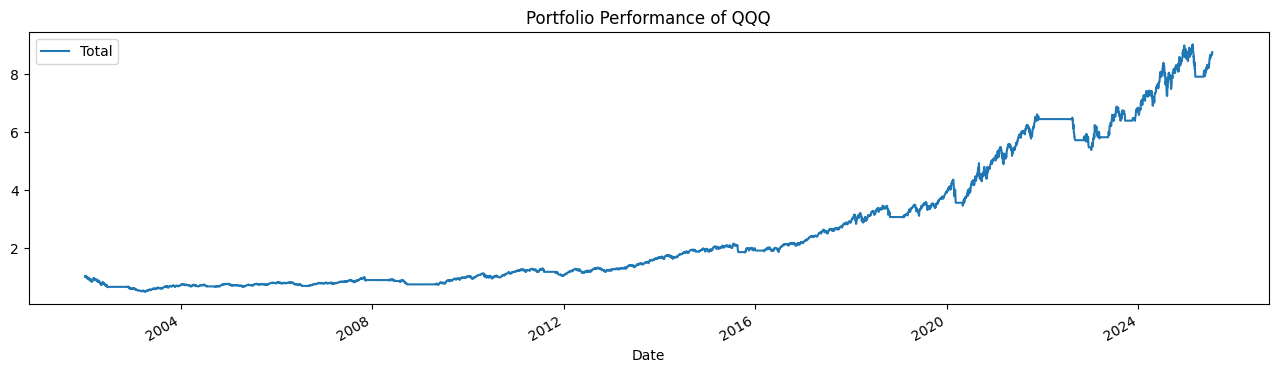

In [11]:
sd = dt.datetime(2002,1,1)
ed = dt.datetime(2025,7,18)
signal_ma_window = 50
buy_threshold = 30
sell_threshold = 30
ticker = qqq

naa200r_performance(qqq, sd, ed, signal_ma_window, buy_threshold , sell_threshold,  visualization=True)

/tmp/ipykernel_69941/3132425936.py:3: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(naa200r.data.sort_index()[['Close']].rolling(20).mean(), label='MA20')


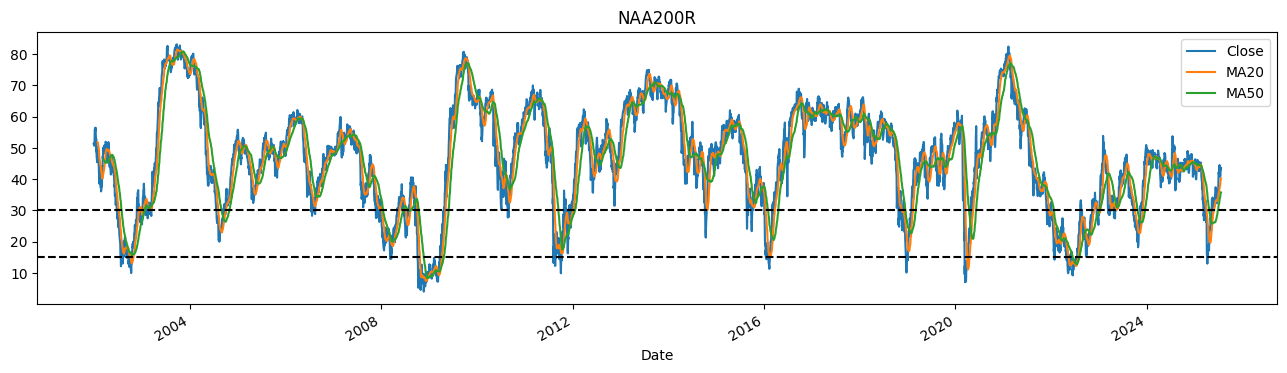

<Axes: xlabel='Date'>

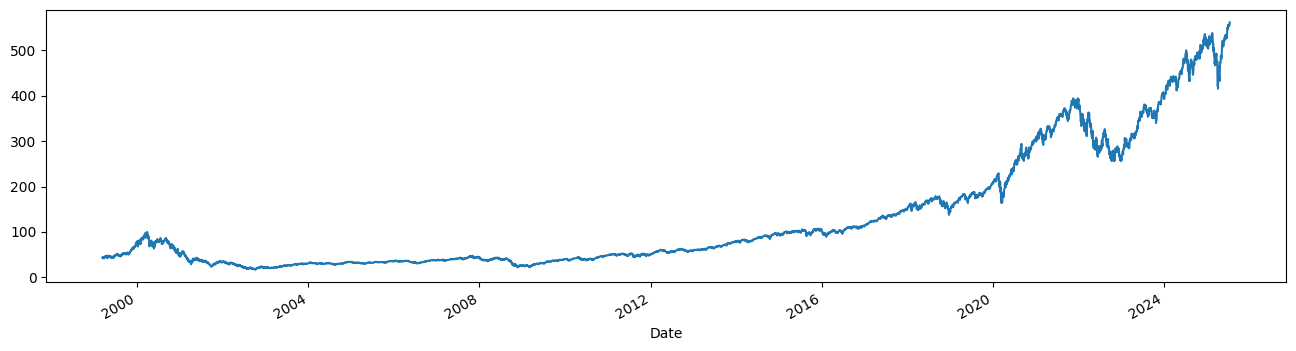

In [12]:
fig = plt.figure(figsize=(16,4))
naa200r.data.sort_index()['Close'].plot(title='NAA200R')
plt.plot(naa200r.data.sort_index()[['Close']].rolling(20).mean(), label='MA20')
plt.plot(naa200r.data.sort_index()[['Close']].rolling(50).mean(), label='MA50')

plt.axhline(y = 15, color = 'black', linestyle='dashed')
plt.axhline(y = 30, color = 'black', linestyle='dashed')
plt.legend()
plt.show()


qqq.data.sort_index()['Close'].plot(figsize=(16,4))